# **Race/Ethnic Classification by Face using MobileNetV2**

`2000 Trainable Images Dataset with 500 Validation Images`

In [1]:
import pandas as pd
import os

# 1. Load file CSV
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 2. Filter hanya kolom yang dibutuhkan (file path dan race)
# Kita pastikan kolom 'file' sesuai dengan lokasi fisik gambar di folder
train_data = train_df[['file', 'race']]
val_data = val_df[['file', 'race']]

# 3. Cek distribusi label (Penting untuk melihat apakah dataset seimbang)
print("Distribusi Ras di Training:")
print(train_data['race'].value_counts())

# 4. Contoh akses data
# Jika folder 'train' berada di dalam directory yang sama dengan script:
# train_data['full_path'] = 'data_dir/' + train_data['file']

print("\nData siap diproses!")
print(train_data.head())

Distribusi Ras di Training:
race
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64

Data siap diproses!
          file        race
0  train/1.jpg  East Asian
1  train/2.jpg      Indian
2  train/3.jpg       Black
3  train/4.jpg      Indian
4  train/5.jpg      Indian


## **Resampling Data serta Ekstraksi Label & Setup Data Generator**

` Menggunakan jumlah gambar 2000 untuk train - 500 untuk validation `


In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load file CSV sesuai nama terbaru
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 1.1 Pastikan nama kolom bersih dari spasi tersembunyi
train_df.columns = train_df.columns.str.strip()
val_df.columns = val_df.columns.str.strip()

# 1.2 Verifikasi ulang setelah dibersihkan (opsional)
print("Kolom yang terdeteksi:", train_df.columns.tolist())

# 1.3 Eksekusi Strategi 1: 2000 Train - 500 Validation
try:
    # Menggunakan metode .sample() bawaan groupby (Jauh lebih aman!)
    train_df_800 = train_df.groupby('race').sample(n=2000, random_state=42).reset_index(drop=True)
    val_df_200 = val_df.groupby('race').sample(n=500, random_state=42).reset_index(drop=True)

    print("\n--- Berhasil Melakukan Resampling ---")
    print("Kolom di Train Baru:", train_df_800.columns.tolist()) 
    print(f"Total Data Latih Baru   : {len(train_df_800)} gambar")
    print(f"Total Data Validasi Baru: {len(val_df_200)} gambar")

except Exception as e:
    print(f"\n[ERROR] Terjadi masalah: {e}")

# 2. Setup Data Generator (Optimasi untuk RAM 5,7GB)
# Kita gunakan rescale 1/255 agar nilai piksel ada di rentang 0-1
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Parameter Penyelamat Memory
IMG_SIZE = (128, 128) 
BATCH_SIZE = 16 # Jika nanti masih terasa berat/crash, turunkan ke 8

# Generator Latih
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_800, # <--- Gunakan df hasil sampling
    directory='Dataset',
    x_col='file',
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df_200,   # <--- Gunakan df hasil sampling
    directory='Dataset',
    x_col='file',
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

I0000 00:00:1777616729.727280    4459 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777616730.286962    4459 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777616734.780419    4459 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Kolom yang terdeteksi: ['file', 'age', 'gender', 'race', 'service_test']

--- Berhasil Melakukan Resampling ---
Kolom di Train Baru: ['file', 'age', 'gender', 'race', 'service_test']
Total Data Latih Baru   : 14000 gambar
Total Data Validasi Baru: 3500 gambar
Found 14000 validated image filenames belonging to 7 classes.
Found 3500 validated image filenames belonging to 7 classes.


## **Arsitektur Model MobileNetV2 (Transfer Learning)**

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 tanpa layer output asli
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(128, 128, 3)
)

# # FREEZE: Jangan latih ulang base model agar hemat komputasi
# base_model.trainable = False 
base_model.trainable = True
# Freeze semua layer kecuali 30 layer terakhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Tambahkan layer baru khusus untuk klasifikasi Ras
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x) # Memberikan sedikit ruang agar model tidak kaku

# Output layer menyesuaikan jumlah ras di dataset
num_classes = len(train_generator.class_indices)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # LR lebih kecil agar stabil
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

model.summary()

E0000 00:00:1777616749.287996    4459 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 1,691,271 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

## **Training Model**

Epoch 1/20


I0000 00:00:1777616763.994348    4459 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1777616787.507825    4710 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.
W0000 00:00:1777616787.552511    4710 cpu_allocator_impl.cc:82] Allocation of 25958400 exceeds 10% of free system memory.


  1/875 ━━━━━━━━━━━━━━━━━━━━ 5:56:17 24s/step - accuracy: 0.2500 - auc: 0.6094 - loss: 1.9972 - precision: 0.0000e+00 - recall: 0.0000e+00

W0000 00:00:1777616788.536025    4711 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.
W0000 00:00:1777616788.603146    4711 cpu_allocator_impl.cc:82] Allocation of 25958400 exceeds 10% of free system memory.


  2/875 ━━━━━━━━━━━━━━━━━━━━ 14:16 981ms/step - accuracy: 0.2031 - auc: 0.5801 - loss: 2.0570 - precision: 0.0000e+00 - recall: 0.0000e+00

W0000 00:00:1777616789.463713    4711 cpu_allocator_impl.cc:82] Allocation of 25165824 exceeds 10% of free system memory.


875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.2471 - auc: 0.6312 - loss: 1.9065 - precision: 0.4204 - recall: 0.0394
Epoch 1: val_accuracy improved from None to 0.32741, saving model to output/model_race_2000.keras

Epoch 1: finished saving model to output/model_race_2000.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 547s 598ms/step - accuracy: 0.2906 - auc: 0.6859 - loss: 1.7847 - precision: 0.5427 - recall: 0.0654 - val_accuracy: 0.3274 - val_auc: 0.7270 - val_loss: 1.7124 - val_precision: 0.5501 - val_recall: 0.0960 - learning_rate: 1.0000e-04
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.3951 - auc: 0.7770 - loss: 1.5634 - precision: 0.6516 - recall: 0.1440
Epoch 2: val_accuracy improved from 0.32741 to 0.33544, saving model to output/model_race_2000.keras

Epoch 2: finished saving model to output/model_race_2000.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 565s 602ms/step - accuracy: 0.3969 - auc: 0.7822 - loss: 1.5501 - precision: 0.6341 - recall: 0.1524 - val_accurac

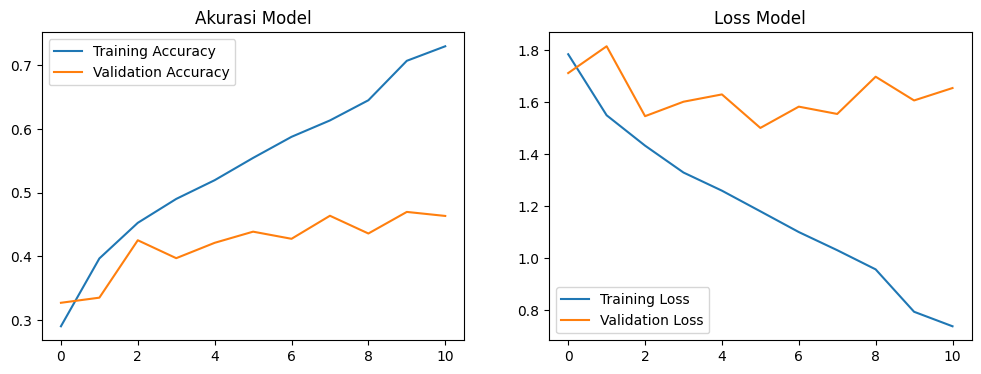

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os
if not os.path.exists('output'):
    os.makedirs('output')

# 1. KONFIGURASI CALLBACKS
# EarlyStopping: Menghentikan training jika val_loss tidak turun selama 5 epoch berturut-turut.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Menurunkan learning rate jika akurasi mulai mentok.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint: Otomatis menyimpan model terbaik yang berhasil dilatih.
checkpoint = ModelCheckpoint(
    'output/model_race_2000.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# checkpoint = ModelCheckpoint(
#     'output/model_race_2000.keras',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# 2. PROSES TRAINING
# Kita mulai dengan 20 epoch. EarlyStopping kemungkinan akan menghentikannya lebih cepat.
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# 3. VISUALISASI HASIL
# Membuat grafik Akurasi dan Loss untuk melihat performa model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Model')
plt.legend()
plt.show()

## **Metrik Evaluasi menggunakan Validation Data**

219/219 ━━━━━━━━━━━━━━━━━━━━ 71s 318ms/step


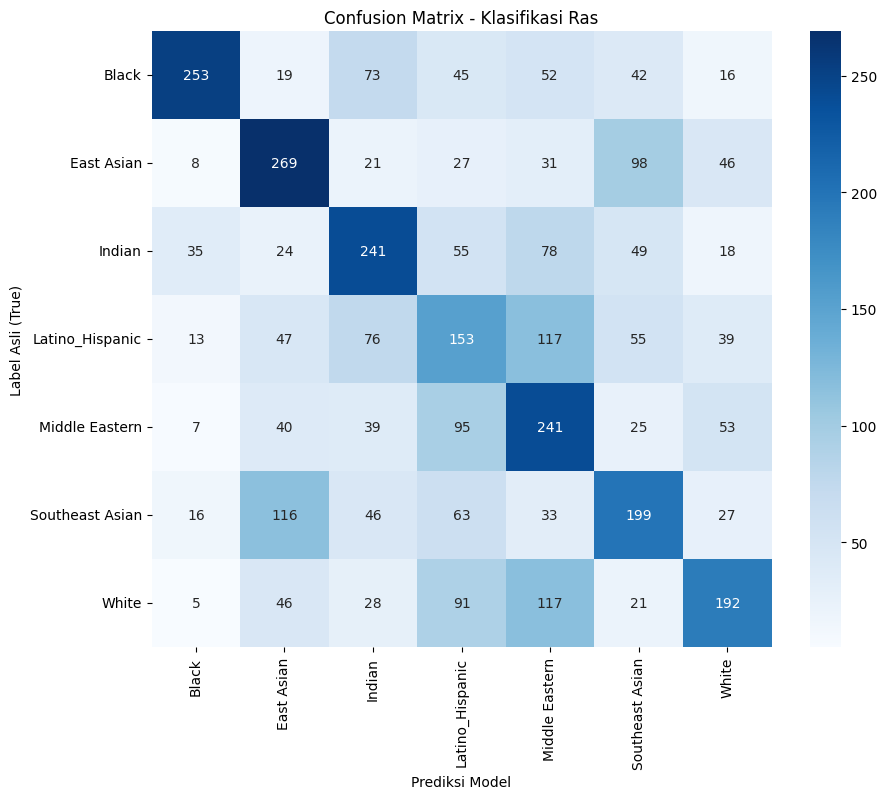


--- Laporan Klasifikasi (Metrik Evaluasi) ---
                 precision    recall  f1-score   support

          Black       0.75      0.51      0.60       500
     East Asian       0.48      0.54      0.51       500
         Indian       0.46      0.48      0.47       500
Latino_Hispanic       0.29      0.31      0.30       500
 Middle Eastern       0.36      0.48      0.41       500
Southeast Asian       0.41      0.40      0.40       500
          White       0.49      0.38      0.43       500

       accuracy                           0.44      3500
      macro avg       0.46      0.44      0.45      3500
   weighted avg       0.46      0.44      0.45      3500



In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil label asli dan prediksi dari validation generator
val_generator.reset() # Reset agar urutan tidak berantakan
Y_pred = model.predict(val_generator, steps=val_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Ambil nama-nama kelas (Ras)
class_labels = list(val_generator.class_indices.keys())

# 3. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualisasi dengan Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ras')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model')
plt.show()

# 5. Print Metrik Evaluasi Lengkap (Precision, Recall, F1-Score)
print("\n--- Laporan Klasifikasi (Metrik Evaluasi) ---")
print(classification_report(y_true, y_pred, target_names=class_labels))